In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- 1. 基础组件 ---
class EncoderA(nn.Module): # 处理 20x20
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            # 1. Input: 1 x 513 x 125
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=(1, 1)),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),  # 使用 LeakyReLU
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # 20x20
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 10x10
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128)
        )
        self.flat_size_a = 128*5*5
        self.fc_mu = nn.Linear(self.flat_size_a, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_size_a, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)
    
class EncoderB(nn.Module): # 处理 41x41
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1),   # (1,20,20) -> (8,20,20)
            nn.BatchNorm2d(8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(8, 16, kernel_size=4, stride=2,padding=1),  # -> (16,10,10)
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.2, inplace=True),  
            nn.Conv2d(16, 64, kernel_size=4, stride=2, padding=1), # 5x5
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True)# -> (16,5,5)
        )
        self.flat_size_b = 64*5*5
        self.fc_mu = nn.Linear(self.flat_size_b, 16)
        self.fc_logvar = nn.Linear(self.flat_size_b, 16)

    def forward(self, x):
        h = self.conv(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

class Decoder(nn.Module): # 还原 41x41
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(latent_dim, 32*11*11), nn.ReLU())
        self.deconv = nn.Sequential(
            nn.Unflatten(1, (32, 11, 11)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=0), # 21x21
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=0),  # 41x41
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.deconv(self.fc(z))

# --- 2. 核心融合模块 ---
class LatentAttentionFusion(nn.Module):
    def __init__(self, feat_dim=16):
        super().__init__()
        self.q = nn.Linear(feat_dim, feat_dim)
        self.k = nn.Linear(feat_dim, feat_dim)
        self.v = nn.Linear(feat_dim, feat_dim)

    def forward(self, z_a_feat, z_b_feat):
        # z_b_feat as Query, z_a_feat as Key/Value
        query = self.q(z_b_feat).unsqueeze(1)
        key = self.k(z_a_feat).unsqueeze(1)
        value = self.v(z_a_feat).unsqueeze(1)
        
        attn = torch.bmm(query, key.transpose(1, 2)) / (z_a_feat.size(-1)**0.5)
        weights = F.softmax(attn, dim=-1)
        fused = torch.bmm(weights, value).squeeze(1)
        return fused + z_b_feat # 残差

# --- 3. 完整网络 ---
class DualVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.enc_a = EncoderA(latent_dim)
        self.enc_b = EncoderB(latent_dim)
        self.fusion = LatentAttentionFusion(feat_dim=16)
        self.dec = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x_a, x_b):
        mu_a, logvar_a = self.enc_a(x_a)
        mu_b, logvar_b = self.enc_b(x_b)
        z_a = self.reparameterize(mu_a, logvar_a)
        z_b = self.reparameterize(mu_b, logvar_b)

        fused_feat = self.fusion(z_a, z_b)
        return self.dec(fused_feat), mu_a, logvar_a, mu_b, logvar_b, fused_feat, z_a, z_b

# --- 4. 损失函数 ---
def loss_fn(recon_x, x_a, mu_a, logvar_a, mu_b, logvar_b, z_a, z_b):
    # 重构损失 (针对高清仿真 A)
    mse = F.mse_loss(recon_x, x_a, reduction='mean')
    # KL 散度
    kla = -0.5 * torch.sum(1 + logvar_a - mu_a.pow(2) - logvar_a.exp())
    klb = -0.5 * torch.sum(1 + logvar_b - mu_b.pow(2) - logvar_b.exp())
    
    kl_loss = kla + klb
    # 3. 简单的域对齐 (既然 MMD 嫌粗暴，先用余弦相似度，让规律往一块凑)
    # cos=1表示方向完全一致（型一致），不管大小（值）
    cos_sim = F.cosine_similarity(z_a, z_b).mean()
    align_loss = 1.0 - cos_sim
    
    # 权重分配：重构最重要(1.0)，对齐次之(0.5)，KL给一点点(0.01)
    total_loss = mse + 2 * align_loss + kl_loss
    
    return total_loss

In [3]:
import numpy as np
import random
sim_dir = r"D:\研三\大山1-毕业论文\代码\v41_data\modulus_data_2.npy"
mea_dir = r"D:\研三\大山1-毕业论文\代码\vae upgrade\data_noise_0.1.npy"
data_sim = np.load(sim_dir)
data_mea = np.load(mea_dir)
data_mea = torch.from_numpy(data_mea).float()
data_sim = torch.from_numpy(data_sim).float()

In [4]:
global_max = data_sim.max()
global_min = data_sim.min()
data_sim_n = (data_sim - global_min) /(global_max - global_min)
data_sim_t = data_sim_n.unsqueeze(1)
data_mea_t = data_mea.unsqueeze(1)

In [15]:
import numpy as np

import torch
from torch.utils.data import DataLoader, TensorDataset

def get_dataloader(data_a, data_b, batch_size=32):
    dataset = TensorDataset(data_a, data_b)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)
train_loader = get_dataloader(data_sim_t, data_mea_t, batch_size=32)

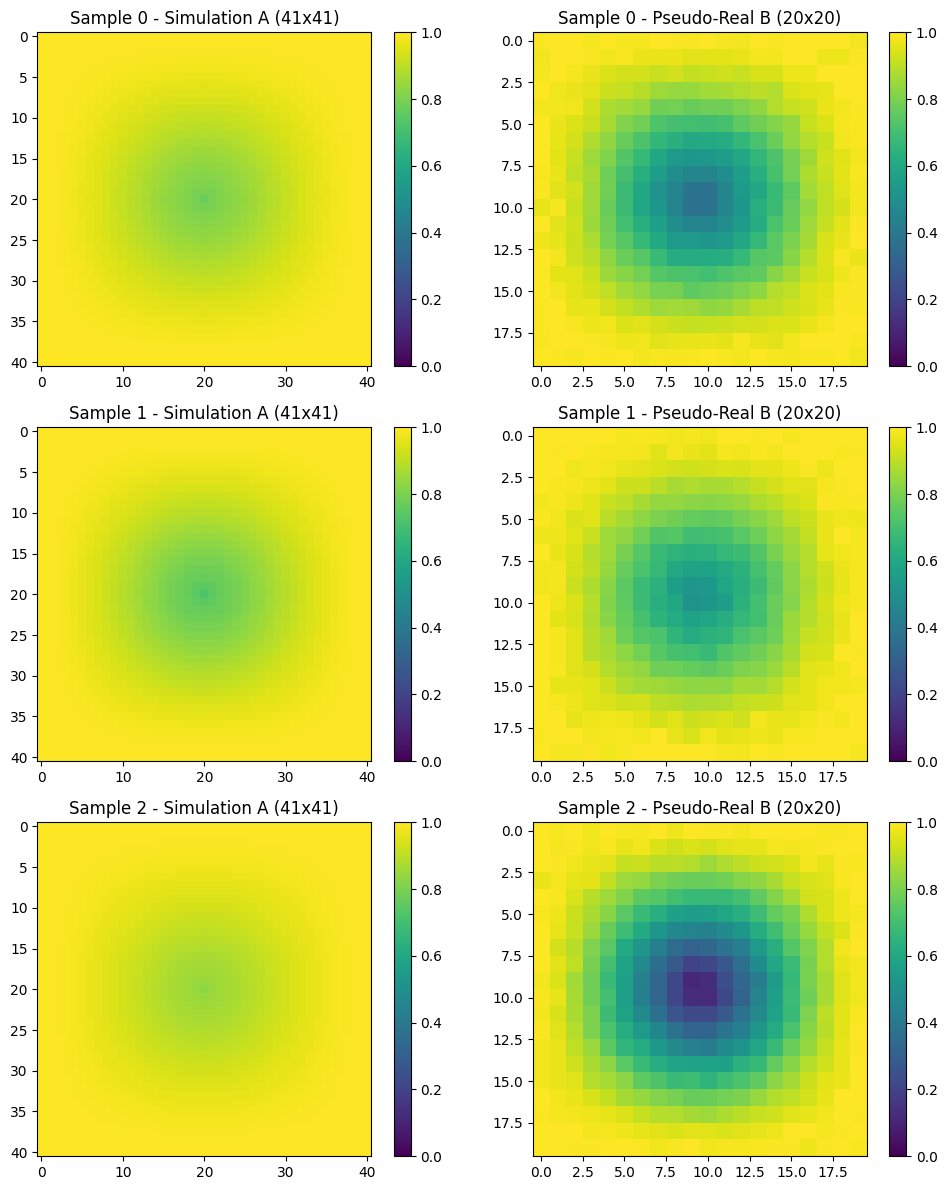

In [45]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def check_alignment(loader, num_samples=3):
    model.eval()
    # 从 loader 中抓取一个 batch
    data_iter = iter(loader)
    batch_a, batch_b = next(data_iter)
    
    # 确保只取 num_samples 个
    samples_a = batch_a[:num_samples]
    samples_b = batch_b[:num_samples]
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples * 4))
    
    for i in range(num_samples):
        # 提取数据并转为 numpy
        img_a = samples_a[i].squeeze().cpu().numpy()
        img_b = samples_b[i].squeeze().cpu().numpy()
       
        # 绘制 A (41x41)
        im1 = axes[i, 0].imshow(img_a, cmap='viridis',vmin=0, vmax=1)
        axes[i, 0].set_title(f"Sample {i} - Simulation A (41x41)")
        plt.colorbar(im1, ax=axes[i, 0])
        
        # 绘制 B (20x20)
        im2 = axes[i, 1].imshow(img_b, cmap='viridis',vmin=0, vmax=1)
        axes[i, 1].set_title(f"Sample {i} - Pseudo-Real B (20x20)")
        plt.colorbar(im2, ax=axes[i, 1])
        
    plt.tight_layout()
    plt.show()

# 执行检查
check_alignment(train_loader)

In [39]:
# 实例化模型
latent_dim = 16
model = DualVAE(latent_dim=latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

# 4. 训练循环示例
model.train()
for epoch in range(400):
    total_loss = 0
    for x_a, x_b in train_loader:
            x_a, x_b = x_a.float(), x_b.float()
            optimizer.zero_grad()
            # 前向传播
            # 注意：因为权重冻结，这里的 sig_a, sig_b 产生的索引 (2, 4) 是固定的物理特征
            recon_x, mu_a, logvar_a, mu_b, logvar_b, fused_feat, z_a, z_b= model(x_a, x_b)
            loss = loss_fn(recon_x, x_a, mu_a, logvar_a, mu_b, logvar_b, z_a, z_b)
            loss.backward()
            optimizer.step()
            
            
            total_loss += loss.item()    
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 0 | Loss: 30.5875
Epoch 50 | Loss: 2.1758
Epoch 100 | Loss: 2.1068
Epoch 150 | Loss: 2.0342
Epoch 200 | Loss: 2.0579
Epoch 250 | Loss: 2.0777
Epoch 300 | Loss: 2.0674
Epoch 350 | Loss: 2.0880


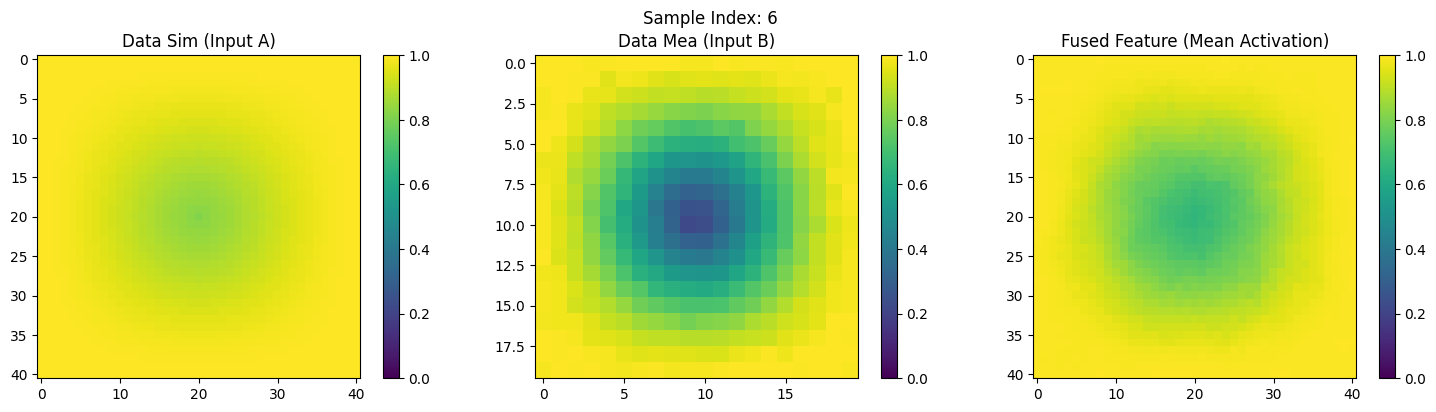

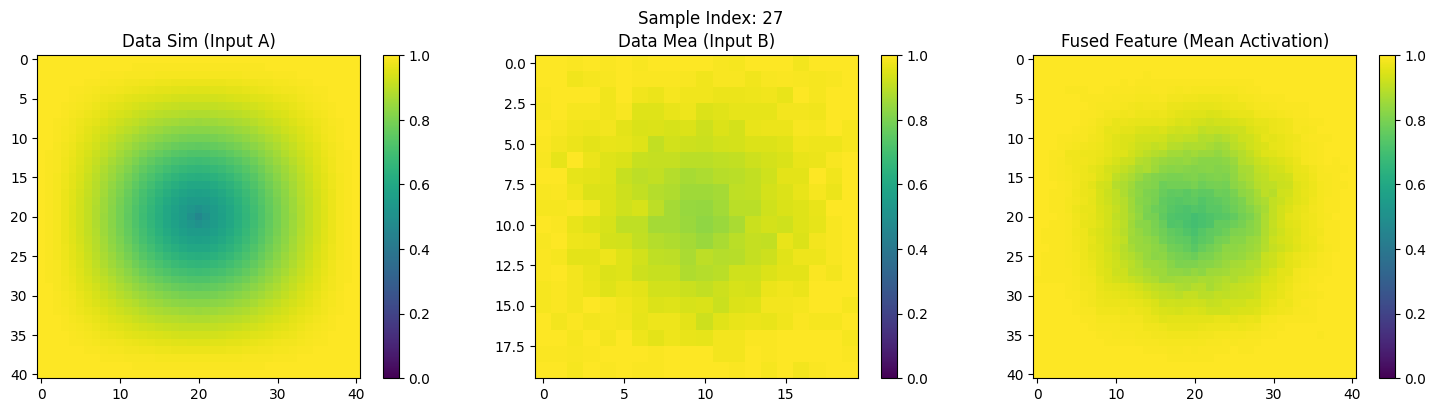

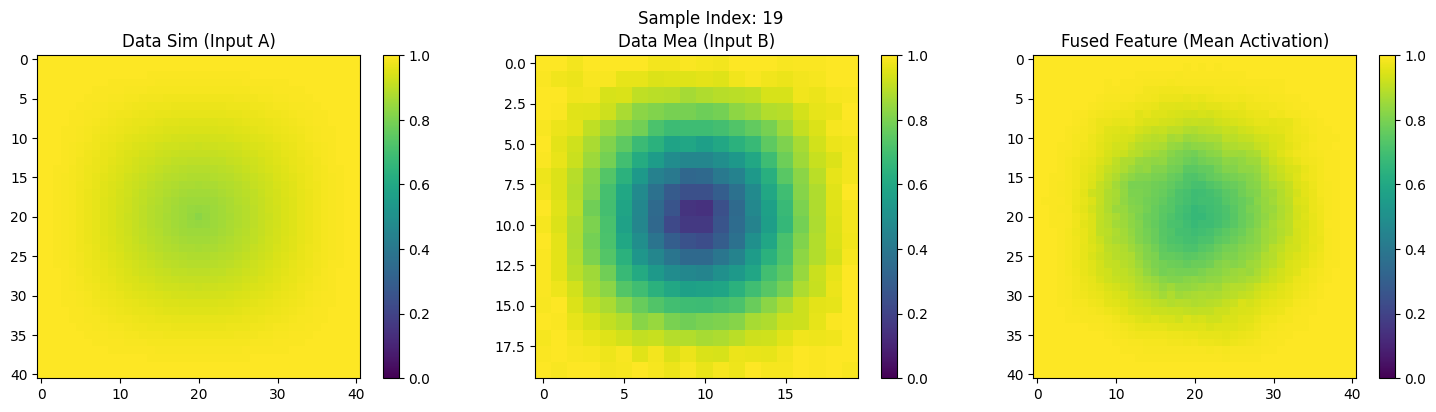

In [46]:
import matplotlib.pyplot as plt
def show_three_way_comparison(model, loader, K=5, cmap='viridis'):
    model.eval()
    with torch.no_grad():
        # 1. 取出一组数据
        batch = next(iter(loader))
        x_a, x_b = batch[0], batch[1] # sim 和 mea

        # 2. 前向传播 (根据你之前的 model 返回结构)
        # 假设返回顺序: recon_x, mu_a, logvar_a, mu_b, logvar_b, fused_feat, z_a, z_b
        out = model(x_a, x_b)
        recon_x = out[0]
        #print(recon_x.shape)

        B = x_a.size(0)
        K = min(K, B)
        idxs = torch.randperm(B)[:K]

        for idx in idxs:
            # 准备绘图数据
            # [idx, 0] 表示取该样本的第1个通道 (C, H, W) -> (H, W)
            img_sim = x_a[idx, 0].detach().cpu()
            img_mea = x_b[idx, 0].detach().cpu()
            img_fuse = recon_x[idx, 0].detach().cpu()
            

            # 创建画布：1行3列
            plt.figure(figsize=(15, 4))
            plt.suptitle(f"Sample Index: {int(idx)}")

            # 图1: Simulated Data
            plt.subplot(1, 3, 1)
            plt.title("Data Sim (Input A)")
            plt.imshow(img_sim, cmap=cmap,vmin=0,vmax=1)
            plt.colorbar()

            # 图2: Measured Data
            plt.subplot(1, 3, 2)
            plt.title("Data Mea (Input B)")
            plt.imshow(img_mea, cmap=cmap,vmin=0,vmax=1)
            plt.colorbar()

            # 图3: Fused Feature (Hidden Layer)
            plt.subplot(1, 3, 3)
            plt.title("Fused Feature (Mean Activation)")
            plt.imshow(img_fuse, cmap=cmap, vmin=0,vmax=1) # 融合特征用不同色系更容易区分
            plt.colorbar()

            plt.tight_layout()
            plt.show()

# 使用方法
show_three_way_comparison(model, train_loader, K=3)